In [38]:
import sys
from pathlib import Path
# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from sionna.rt import load_scene, RadioMapSolver, Camera, transform_mesh, MeshRadioMap, PlanarRadioMap
from src.utils import extract_building_positions_from_scene, get_antenna_positions, get_scene_bounds
from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array
import numpy as np

In [39]:
# Define parameters
NUM_DEPLOYMENT_BUILDINGS = 3  # number of buildings to deploy base stations on
ANTENNA_HEIGHT_OFFSET = 10.0  # height offset of antennas from the roof
SCENE_CENTER = [0.0, 0.0]  # center of the scene
USER_SHIFT_FROM_GROUND = 1.5  # shift in meters of users from the ground plane or ground mesh
scene_dir = Path("../scenes/boston_1/")  # path to the scene directory
scene_xml_path = scene_dir / "scene.xml"  # path to the scene XML file

# TX antenna array parameters
TX_NUM_ROWS = 8
TX_NUM_COLS = 8
TX_VERTICAL_SPACING = 0.5
TX_HORIZONTAL_SPACING = 0.5
TX_PATTERN = "tr38901"
TX_POLARIZATION = "cross"

# Base station parameters
NUM_SECTORS = 6
MECHANICAL_TILT = 10.0  # degrees
AZIMUTH_OFFSET = 0.0  # degrees
TX_POWER_DBM = 43.0  # dBm
DISPLAY_RADIUS = 15.0  # meters

# Radio map solver parameters
DIFFUSE_REFLECTION = True
DIFFRACTION = True
EDGE_DIFFRACTION = True
MAX_DEPTH = 5  # maximum number of ray scene interactions
SAMPLES_PER_TX = 10**8  # higher = less noise, but more memory required

In [40]:
# merge_shapes=False prevents the building walls and roofs from being merged into a single object
scene = load_scene(scene_xml_path, merge_shapes=False) 
# get the bounding box of the scene
bbox_min, bbox_max = get_scene_bounds(scene)

# Detect if elevation data is present by checking for lidar_terrain.ply file
lidar_terrain_path = scene_dir / "mesh" / "lidar_terrain.ply"  # this file does not exist if lidar elevation data is not present
has_elevation = lidar_terrain_path.exists()

if has_elevation:
    # Get terrain object (Sionna maps lidar_terrain.ply to ground)
    terrain_obj = scene.objects.get("ground")
    # if ground is a mesh and it is mesh if elevation data is present, clone it and
    # transform it to USER_SHIFT_FROM_GROUND meters above the ground
    if terrain_obj:
        measurement_surface = terrain_obj.clone(as_mesh=True)
        transform_mesh(measurement_surface, translation=[0,0,USER_SHIFT_FROM_GROUND])
    # if ground is not a mesh, we will use a plane which does not require measurement surface parameter in Sionna
    else:
        measurement_surface = None
else:
    measurement_surface = None

# Extract building positions from the loaded scene object
building_positions = extract_building_positions_from_scene(scene)
antenna_information = get_antenna_positions(
    building_positions, 
    scene_center=SCENE_CENTER,
    antenna_height_offset=ANTENNA_HEIGHT_OFFSET,
    num_deployment_buildings=NUM_DEPLOYMENT_BUILDINGS)

2026-01-17 01:15:58 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


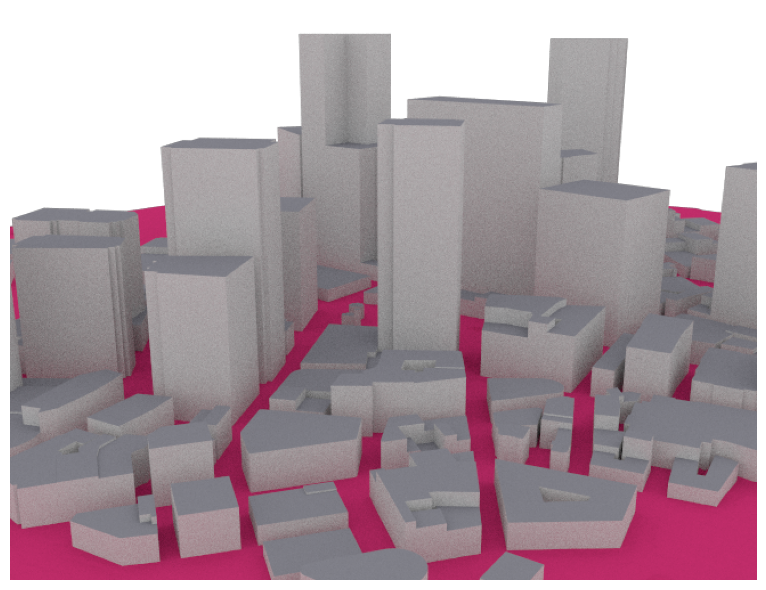

In [41]:
# Position camera at a good viewing distance from the scene center and look at the scene center
camera = Camera(position=bbox_max, look_at=[0, 0, 0])
scene.render(camera=camera);

In [42]:
# set tx and rx specs and add base stations
set_tx_antenna_array(
    scene,
    num_rows=TX_NUM_ROWS,
    num_cols=TX_NUM_COLS,
    vertical_spacing=TX_VERTICAL_SPACING,
    horizontal_spacing=TX_HORIZONTAL_SPACING,
    pattern=TX_PATTERN,
    polarization=TX_POLARIZATION)

# For radio map solver, receive antenna array params are assumed fixed
# and modifying them does not matter. See below from the Sionna RT technical report:
# The receive antenna pattern is not applied here. Instead, the squared norm of the
# electric field is used. This is equivalent to assuming that a receiver positioned
# on the measurement plane uses a dual-polarized isotropic antenna, and that both components are combined non-coherently.
set_rx_antenna_array(
    scene,
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="VH"
)

# add base stations
for i, current_antenna_information in enumerate(antenna_information):
    bs_name = f"BS_{i}"
    _, antenna_position = current_antenna_information
    print(f"Adding base station {bs_name} at position {antenna_position}")
    add_base_station(
        scene,
        bs_name,
        position=antenna_position,
        num_sectors=NUM_SECTORS,
        mechanical_tilt=MECHANICAL_TILT,
        azimuth_offset=AZIMUTH_OFFSET,
        tx_power_dbm=TX_POWER_DBM,
        display_radius=DISPLAY_RADIUS
    )

Antenna Array Configuration Set:
  - Array: 8x8 (128 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [15.3]°
UE Antenna Array Configuration Set:
  - Array: 1x1 (2 elements)
  - Pattern: iso, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Adding base station BS_0 at position [-55.30364227294922, -73.86759948730469, 220.5]
Added BS_0_sector_1 at position [[-55.3036, -73.8676, 220.5]], azimuth 0.0°
Added BS_0_sector_2 at position [[-55.3036, -73.8676, 220.5]], azimuth 60.0°
Added BS_0_sector_3 at position [[-55.3036, -73.8676, 220.5]], azimuth 120.0°
Added BS_0_sector_4 at position [[-55.3036, -73.8676, 220.5]], azimuth 180.0°
Added BS_0_sector_5 at position [[-55.3036, -73.8676, 220.5]], azimuth 240.0°
Added BS_0_sector_6 at position [[-55.3036, -73.8676, 220.5]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[-55.3036], [-73.8676], [220.5]] m
Adding base 

In [6]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               measurement_surface=measurement_surface,
               diffuse_reflection=DIFFUSE_REFLECTION,
               diffraction=DIFFRACTION,
               edge_diffraction=EDGE_DIFFRACTION,
               max_depth=MAX_DEPTH,
               samples_per_tx=SAMPLES_PER_TX)

In [7]:
if isinstance(rm, MeshRadioMap):
    scene.preview(radio_map=rm, rm_db_scale=True, rm_metric="path_gain");

In [8]:
if isinstance(rm, PlanarRadioMap):
    rm.show(metric="path_gain", tx=0);

In [45]:
tx_association = rm.tx_association(metric="path_gain").numpy()
valid_association_mask = tx_association != -1
print(f"Percentage of cells with coverage: {np.sum(valid_association_mask) / len(valid_association_mask) * 100:.2f}%")

Percentage of cells with coverage: 96.18%


In [89]:
sampled_positions = rm.sample_positions(
    num_pos=100,
    metric="path_gain",
    min_val_db=-150,
    tx_association=True,
    center_pos=False,
    seed=1
)

In [123]:
# first index have the position, second index have cell id
# the second index is for the tx id, second index have cell id
# the third index is for the position id
print(sampled_positions[0][0][0])  # print the position of the first tx, first cell, first position

[504.01, -13.9762, 1.3512]
